## COMP9517-Lab1
Author:
    Songyu Qi
    z5536858

Image shape: (600, 900)


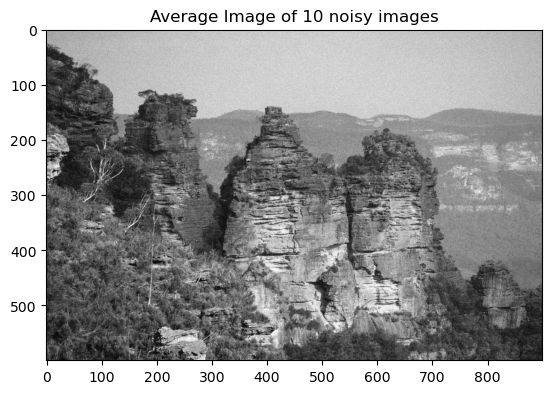

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import time

image_folder = './COMP9517_25T3_Lab1_Images'
images = [cv2.imread(os.path.join(image_folder, f), cv2.IMREAD_GRAYSCALE).astype(np.float32)
 for f in os.listdir(image_folder) 
 if f.endswith('.jpg')]
print("Image shape:", images[0].shape)

average_image = np.mean(images, axis=0)

plt.imshow(average_image, cmap='gray')
plt.title('Average Image of 10 noisy images')
#plt.axis('off')
plt.show()


In [2]:
sigma_avg_single_sky = np.mean([np.std(img[0:100, 600:700]) for img in images])
sigma_single_sky = np.std(images[0][0:100, 600:700])
sigma_avg_sky = np.std(average_image[0:100, 600:700])
reduction_actual = sigma_single_sky - sigma_avg_sky
reduction_ratio = sigma_single_sky / sigma_avg_sky

print("σ_avg_single:", sigma_avg_single_sky)
print("σ_single:", sigma_single_sky)
print("σ_average:", sigma_avg_sky)
print("Actual reduction factor:", reduction_actual)
print("Actual reduction ratio:", reduction_ratio)

σ_avg_single: 24.465878
σ_single: 24.513557
σ_average: 8.391854
Actual reduction factor: 16.121704
Actual reduction ratio: 2.9211133


### 1.Theoretically, how much noise reduction should you be able to achieve this way? That is, by what factor should the standard deviation of the noise drop?

Theoretical reduction: Theoratical_RMSE_averaging = RMSE_Single * reduction_factor


Theoretical reduction_factor = 1/sqrt(len(images)) = 1/sqrt(10) = 0.316

Same viewpoint of images, averaging $N$ images can reduce the noise standard deviation to $1/\sqrt{N}$ of the original.



Measured σ in a flat sky region:

σ_single (single noisy image) = 24.513

σ_average (averaged image of 10 noisy images) = 8.391

Actual noise reduction factor (σ_single / σ_average) ≈ 2.921

Theoretical noise reduction factor for averaging 10 independent images: √10 ≈ 3.16


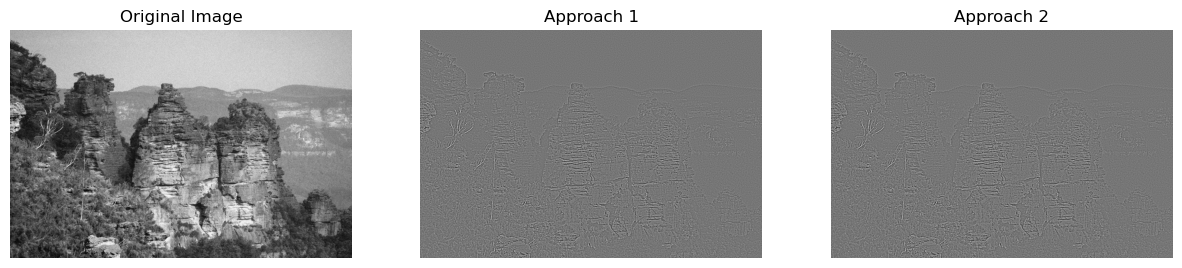

Time taken for approach 1: 0.002655029296875 seconds
Time taken for approach 2: 0.0014719963073730469 seconds
Substract of approach 1 and approach 2: [[ 1.94311142e-05  2.56896019e-05  5.42402267e-06 ... -5.84125519e-06
   2.26497650e-06 -1.29938126e-05]
 [-1.53779984e-05  1.43051147e-06 -1.75833702e-05 ... -1.23381615e-05
   3.40938568e-05  2.50339508e-06]
 [-1.18017197e-05  3.16500664e-05 -2.84910202e-05 ...  1.07288361e-05
   7.45058060e-06  2.86698341e-05]
 ...
 [ 5.72204590e-06  5.72204590e-06  2.38418579e-06 ...  4.50015068e-06
  -1.63912773e-07 -4.76837158e-07]
 [ 2.38418579e-06 -5.40912151e-06 -4.76837158e-07 ...  2.23517418e-06
   3.21865082e-06 -2.90572643e-06]
 [ 6.19888306e-06  2.86102295e-06  1.60932541e-06 ... -2.13086605e-06
  -1.19209290e-06 -1.19209290e-06]]


In [3]:
h1 = np.array([[0,0,0,0,0],[0,1,2,1,0],[0,2,4,2,0],[0,1,2,1,0],[0,0,0,0,0]], dtype=np.float32) / 16
h2 = np.array([[1,4,6,4,1],[4,16,24,16,4],[6,24,36,24,6],[4,16,24,16,4],[1,4,6,4,1]], dtype=np.float32) / 256

#apporaches1:
t1_start = time.time()
approach1 = cv2.filter2D(average_image, -1, h1 - h2)
t1_end = time.time()
#apporaches2:
t2_start = time.time()
approach2 = cv2.filter2D(average_image, -1, h1) - cv2.filter2D(average_image, -1, h2)
t2_end = time.time()

plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
plt.imshow(average_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(approach1, cmap='gray')
plt.title('Approach 1')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(approach2, cmap='gray')
plt.title('Approach 2')
plt.axis('off')
plt.show()

print(f"Time taken for approach 1: {t1_end - t1_start} seconds")
print(f"Time taken for approach 2: {t2_end - t2_start} seconds")

subtract = approach1 - approach2
print(f"Substract of approach 1 and approach 2: {subtract}")



**The first approach is faster**. Because it only calculate convolution once, the second approach calculate convolution twice.

**The result aboult subtract from apporach1 and approach2 is not 0**. The reason for this result is the presence of floating-point precision errors in the computation. This is a normal phenomenon, and the difference is so small that it can be safely ignored.

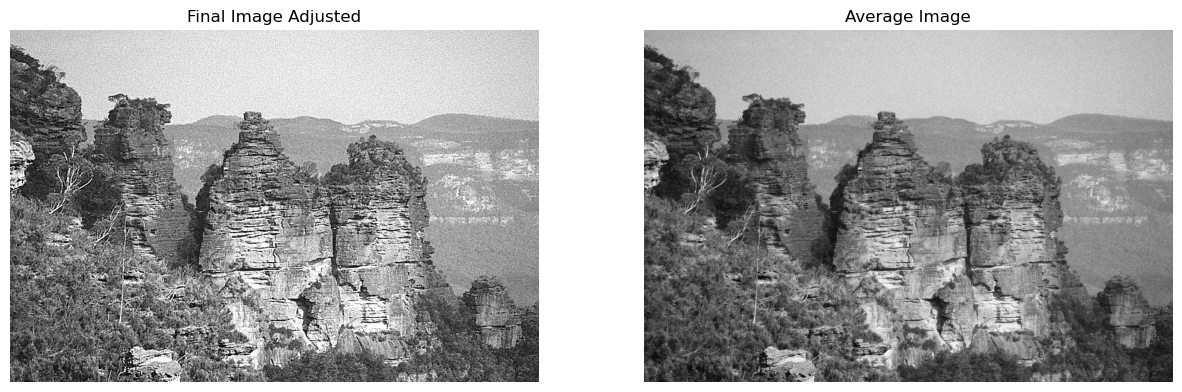

In [4]:
final_image = approach1 * 5 + average_image
contrast = 1.1
brightness = 8.0
final_image_adjusted = final_image * contrast + brightness
final_image_adjusted = np.clip(final_image_adjusted, 0.0, 255.0)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.imshow(final_image_adjusted, cmap='gray')
plt.title('Final Image Adjusted')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(average_image, cmap='gray')
plt.title('Average Image')
plt.axis('off')
plt.show()

We only want to get a nice photo without noise in Task 1. So, besides edge sharpness, the **high-frequency noise**, **small texture details**, and **local contrast variations** are amplified in Task 3, which we were trying to get rid of in Task 1.

Theoretical reason: DoG approximates the Laplacian, which is **sensitive to rapid intensity changes**. 

Edges, noise, and fine textures are all amplified.

Smooth, low-frequency areas are suppressed.